## Import modules

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

#import table processing scripts
import utils.data_processing_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table


In [2]:
# show full df
# pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

## set up pyspark session

In [3]:
# Initialize SparkSession (cluster)
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/02 09:00:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## EDA

pandas used for EDA as the dataset is small

In [4]:
filenames = os.listdir("data")
print("There are",len(filenames),"files. Their names are", filenames)

There are 4 files. Their names are ['features_attributes.csv', 'features_financials.csv', 'feature_clickstream.csv', 'lms_loan_daily.csv']


'features_attributes.csv', 'features_financials.csv', 'feature_clickstream.csv' are used to create the feature store <br>
'lms_loan_daily.csv' is used to create the label store

In [5]:
dir_prefix = "data"
df_attr = pd.read_csv(os.path.join(dir_prefix,filenames[0]))
df_attr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer_ID    12500 non-null  object
 1   Name           12500 non-null  object
 2   Age            12500 non-null  object
 3   SSN            12500 non-null  object
 4   Occupation     12500 non-null  object
 5   snapshot_date  12500 non-null  object
dtypes: object(6)
memory usage: 586.1+ KB


In [6]:
df_financial = pd.read_csv(os.path.join(dir_prefix,filenames[1]))
df_financial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               12500 non-null  object 
 1   Annual_Income             12500 non-null  object 
 2   Monthly_Inhand_Salary     12500 non-null  float64
 3   Num_Bank_Accounts         12500 non-null  int64  
 4   Num_Credit_Card           12500 non-null  int64  
 5   Interest_Rate             12500 non-null  int64  
 6   Num_of_Loan               12500 non-null  object 
 7   Type_of_Loan              11074 non-null  object 
 8   Delay_from_due_date       12500 non-null  int64  
 9   Num_of_Delayed_Payment    12500 non-null  object 
 10  Changed_Credit_Limit      12500 non-null  object 
 11  Num_Credit_Inquiries      12500 non-null  float64
 12  Credit_Mix                12500 non-null  object 
 13  Outstanding_Debt          12500 non-null  object 
 14  Credit

In [7]:
df_clickstream = pd.read_csv(os.path.join(dir_prefix,filenames[2]))
df_clickstream.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215376 entries, 0 to 215375
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   fe_1           215376 non-null  int64 
 1   fe_2           215376 non-null  int64 
 2   fe_3           215376 non-null  int64 
 3   fe_4           215376 non-null  int64 
 4   fe_5           215376 non-null  int64 
 5   fe_6           215376 non-null  int64 
 6   fe_7           215376 non-null  int64 
 7   fe_8           215376 non-null  int64 
 8   fe_9           215376 non-null  int64 
 9   fe_10          215376 non-null  int64 
 10  fe_11          215376 non-null  int64 
 11  fe_12          215376 non-null  int64 
 12  fe_13          215376 non-null  int64 
 13  fe_14          215376 non-null  int64 
 14  fe_15          215376 non-null  int64 
 15  fe_16          215376 non-null  int64 
 16  fe_17          215376 non-null  int64 
 17  fe_18          215376 non-null  int64 
 18  fe_1

In [8]:
df_label = pd.read_csv(os.path.join(dir_prefix,filenames[3]))
df_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137500 entries, 0 to 137499
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   loan_id          137500 non-null  object 
 1   Customer_ID      137500 non-null  object 
 2   loan_start_date  137500 non-null  object 
 3   tenure           137500 non-null  int64  
 4   installment_num  137500 non-null  int64  
 5   loan_amt         137500 non-null  int64  
 6   due_amt          137500 non-null  float64
 7   paid_amt         137500 non-null  float64
 8   overdue_amt      137500 non-null  float64
 9   balance          137500 non-null  float64
 10  snapshot_date    137500 non-null  object 
dtypes: float64(4), int64(3), object(4)
memory usage: 11.5+ MB


## Set up config

In [9]:
# set up config
start_date_str = "2023-01-01" #df_attr["snapshot_date"].min()
end_date_str = "2024-12-01" #df_attr["snapshot_date"].max()

Since all datasets have `snapshot_date`, can configure the dates to partition using that OR state a static date as seen in `lab_2`

In [10]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
dates_str_lst

['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01']

## Building Bronze Tables

In [11]:
# create bronze datalake
bronze_lms_directory = "datamart/bronze/lms/"
bronze_attributes_directory = "datamart/bronze/attributes/"
bronze_financials_directory = "datamart/bronze/financials/"
bronze_clickstream_directory = "datamart/bronze/clickstream/"

if not os.path.exists(bronze_lms_directory):
    os.makedirs(bronze_lms_directory)

if not os.path.exists(bronze_attributes_directory):
    os.makedirs(bronze_attributes_directory)

if not os.path.exists(bronze_financials_directory):
    os.makedirs(bronze_financials_directory)

if not os.path.exists(bronze_clickstream_directory):
    os.makedirs(bronze_clickstream_directory)

In [12]:
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_lms_directory, spark)
    utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_attributes_directory, spark)
    utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_financials_directory, spark)
    utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_clickstream_directory, spark)

2023-01-01row count: 530


saved to: datamart/bronze/lms/bronze_loan_daily_2023_01_01.parquet
2023-01-01row count: 530


saved to: datamart/bronze/attributes/bronze_attributes_2023_01_01.parquet
2023-01-01row count: 530


saved to: datamart/bronze/financials/bronze_financials_2023_01_01.parquet
2023-01-01row count: 8974


saved to: datamart/bronze/clickstream/bronze_clickstream_2023_01_01.parquet
2023-02-01row count: 1031


...

saved to: datamart/bronze/clickstream/bronze_clickstream_2024_11_01.parquet
2024-12-01row count: 5531


saved to: datamart/bronze/lms/bronze_loan_daily_2024_12_01.parquet
2024-12-01row count: 515


saved to: datamart/bronze/attributes/bronze_attributes_2024_12_01.parquet
2024-12-01row count: 515


saved to: datamart/bronze/financials/bronze_financials_2024_12_01.parquet
2024-12-01row count: 8974


saved to: datamart/bronze/clickstream/bronze_clickstream_2024_12_01.parquet


In [13]:
# inspect output
utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_lms_directory, spark).toPandas()

2024-12-01row count: 5531


saved to: datamart/bronze/lms/bronze_loan_daily_2024_12_01.parquet


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000,1000.0,1000.0,0.0,1000.0,2024-12-01
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000,1000.0,0.0,6000.0,8000.0,2024-12-01
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2024-12-01
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000,0.0,0.0,0.0,10000.0,2024-12-01
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000,1000.0,0.0,9000.0,9000.0,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,8,10000,1000.0,1000.0,0.0,2000.0,2024-12-01
5527,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,6,10000,1000.0,1000.0,0.0,4000.0,2024-12-01
5528,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,0,10000,0.0,0.0,0.0,10000.0,2024-12-01
5529,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2024-12-01


In [14]:
utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_attributes_directory, spark).toPandas()

2024-12-01row count: 515


saved to: datamart/bronze/attributes/bronze_attributes_2024_12_01.parquet


,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x103e,Tim Kellyf,40,155-72-8070,Scientist,2024-12-01
1,CUS_0x1195,Alexk,31,822-48-3629,Manager,2024-12-01
2,CUS_0x1197,Nayako,28,799-23-8283,_______,2024-12-01
3,CUS_0x11e2,Valetkevitchr,34,809-04-1419,Musician,2024-12-01
4,CUS_0x11ec,William Schombergh,34,417-74-2163,Journalist,2024-12-01
...,...,...,...,...,...,...
510,CUS_0xe6c,Doris Frankelh,26,172-24-1577,Entrepreneur,2024-12-01
511,CUS_0xe99,Moone,48,164-90-3178,Mechanic,2024-12-01
512,CUS_0xf55,Tarmo Virkip,39,025-54-8593,Entrepreneur,2024-12-01
513,CUS_0xfd1,Frewy,32,389-55-6408,Architect,2024-12-01


In [15]:
utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_financials_directory, spark).toPandas()

2024-12-01row count: 515


saved to: datamart/bronze/financials/bronze_financials_2024_12_01.parquet


,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x103e,98690.8,8262.233333,4,6,9,1_,Student Loan,6,17,10.76,4.0,Good,706.96,26.860663,26 Years and 11 Months,No,55.004408,913.4813186573292,Low_spent_Small_value_payments,147.7376071067124,2024-12-01
1,CUS_0x1195,30429.91,2808.825833,4,6,16,2,"Auto Loan, and Auto Loan",22,17,1.67,1549.0,Standard,362.48,33.349050,28 Years and 11 Months,No,29.914076,82.87878577514347,Low_spent_Large_value_payments,438.08972109416084,2024-12-01
2,CUS_0x1197,92300.01,7437.667500,2,4,11,3,"Credit-Builder Loan, Not Specified, and Credit-Builder Loan",27,9,18.96,2.0,_,755.17_,26.989787,18 Years and 11 Months,Yes,49236.000000,220.8621525417414,Low_spent_Large_value_payments,581.1567885447394,2024-12-01
3,CUS_0x11e2,44986.55,3689.879167,6,5,11,1,Credit-Builder Loan,0,4,10.26,3.0,Good,753.21,25.586286,20 Years and 0 Months,No,23.267135,43.20363344633164,High_spent_Large_value_payments,542.5171477430948,2024-12-01
4,CUS_0x11ec,14867.69,1005.974167,9,9,18,6,"Debt Consolidation Loan, Student Loan, Personal Loan, Credit-Builder Loan, Auto Loan, and Debt Consolidation Loan",39,15,18.5,8.0,Standard,2344.06,24.344388,17 Years and 2 Months,Yes,55.459604,100.14574834721886,Low_spent_Medium_value_payments,224.99206407779144,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,CUS_0xe6c,125597.52,9367.500187,1,3,12,4,"Debt Consolidation Loan, Not Specified, Student Loan, and Debt Consolidation Loan",2,9,9.89,4.0,Good,1294.94,30.324257,30 Years and 5 Months,NM,1278.186251,964.5381161830327,Low_spent_Medium_value_payments,763.3982127892344,2024-12-01
511,CUS_0xe99,45461.54,3917.461667,6,3,5,2,"Credit-Builder Loan, and Payday Loan",20,9,11.38,6.0,Standard,647.24,27.264685,16 Years and 9 Months,No,69.318349,42.941001590068666,High_spent_Large_value_payments,519.4868162135749,2024-12-01
512,CUS_0xf55,78443.48_,6358.956667,7,5,23,4,"Personal Loan, Home Equity Loan, Mortgage Loan, and Student Loan",39,19,6.37,6.0,Bad,1527.77,24.704429,15 Years and 10 Months,NM,177.387563,528.7469053018515,Low_spent_Medium_value_payments,209.76119880079318,2024-12-01
513,CUS_0xfd1,78666.56999999999,6485.547500,3,4,17,4,"Not Specified, Personal Loan, Home Equity Loan, and Debt Consolidation Loan",29,10,-5.37,3.0,Standard,1498.7,37.831762,22 Years and 5 Months,No,247.851145,252.3461368272953,High_spent_Small_value_payments,408.35746850506007,2024-12-01


In [16]:
utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_clickstream_directory, spark).toPandas()

2024-12-01row count: 8974


saved to: datamart/bronze/clickstream/bronze_clickstream_2024_12_01.parquet


,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,145,189,109,134,196,-37,101,82,111,24,-26,-17,65,249,200,185,-83,-18,-76,30,CUS_0x1037,2024-12-01
1,40,184,187,75,192,146,38,109,353,141,-9,-22,-14,193,125,117,215,91,33,255,CUS_0x1069,2024-12-01
2,98,121,180,200,95,48,59,194,76,84,298,-57,167,101,92,185,98,68,-60,116,CUS_0x114a,2024-12-01
3,85,96,19,47,30,39,-32,210,-81,206,37,105,143,94,139,237,78,187,77,33,CUS_0x1184,2024-12-01
4,98,45,155,56,112,47,52,138,153,225,31,40,-43,142,121,10,189,110,264,241,CUS_0x1297,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8969,414,22,72,57,142,192,11,139,24,63,43,191,179,91,20,189,-35,-19,15,66,CUS_0xdf6,2024-12-01
8970,116,-124,-108,212,-21,227,146,112,186,-65,292,35,38,226,319,98,9,152,17,14,CUS_0xe23,2024-12-01
8971,237,-3,-49,375,144,41,-170,324,19,266,275,80,7,102,64,191,124,220,231,75,CUS_0xe4e,2024-12-01
8972,5,67,211,83,207,-41,325,14,-18,41,133,61,109,266,28,157,131,116,101,131,CUS_0xedd,2024-12-01


## Building Silver Tables

head() to determine the dtype to map for silver table in the `data_processing_silver_table` script

In [12]:
#generate attributes in df in dict form for mapping
dict(zip(df_attr.columns, [StringType()]*len(df_attr.columns)))

{'Customer_ID': StringType(),
 'Name': StringType(),
 'Age': StringType(),
 'SSN': StringType(),
 'Occupation': StringType(),
 'snapshot_date': StringType()}

In [13]:
df_attr.head()

,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x1000,Alistair Barrf,18,913-74-1218,Lawyer,2023-05-01
1,CUS_0x1009,Arunah,26,063-67-6938,Mechanic,2025-01-01
2,CUS_0x100b,Shirboni,19,#F%$D@*&8,Media_Manager,2024-03-01
3,CUS_0x1011,Schneyerh,44,793-05-8223,Doctor,2023-11-01
4,CUS_0x1013,Cameront,44,930-49-9615,Mechanic,2023-12-01


In [14]:
df_attr.isna().sum()

Customer_ID      0
Name             0
Age              0
SSN              0
Occupation       0
snapshot_date    0
dtype: int64

In [15]:
#generate attributes in df in dict form for mapping
dict(zip(df_financial.columns, [StringType()]*len(df_financial.columns)))

{'Customer_ID': StringType(),
 'Annual_Income': StringType(),
 'Monthly_Inhand_Salary': StringType(),
 'Num_Bank_Accounts': StringType(),
 'Num_Credit_Card': StringType(),
 'Interest_Rate': StringType(),
 'Num_of_Loan': StringType(),
 'Type_of_Loan': StringType(),
 'Delay_from_due_date': StringType(),
 'Num_of_Delayed_Payment': StringType(),
 'Changed_Credit_Limit': StringType(),
 'Num_Credit_Inquiries': StringType(),
 'Credit_Mix': StringType(),
 'Outstanding_Debt': StringType(),
 'Credit_Utilization_Ratio': StringType(),
 'Credit_History_Age': StringType(),
 'Payment_of_Min_Amount': StringType(),
 'Total_EMI_per_month': StringType(),
 'Amount_invested_monthly': StringType(),
 'Payment_Behaviour': StringType(),
 'Monthly_Balance': StringType(),
 'snapshot_date': StringType()}

In [16]:
df_financial.isna().sum()

Customer_ID                    0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                1426
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly        0
Payment_Behaviour              0
Monthly_Balance                0
snapshot_date                  0
dtype: int64

In [17]:
df_financial.head()

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x1000,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, and Home Equity Loan",57,26,1.63,11.0,Bad,1562.91,30.077191,10 Years and 9 Months,Yes,42.941090,77.31427572208112,High_spent_Medium_value_payments,400.36080052211616,2023-05-01
1,CUS_0x1009,52312.68_,4250.390000,6,5,17,4,"Not Specified, Home Equity Loan, Credit-Builder Loan, and Payday Loan",5,18,9.73,4.0,_,202.68,40.286997,31 Years and 0 Months,Yes,108.366467,58.66019164829086,High_spent_Medium_value_payments,508.01234122645366,2025-01-01
2,CUS_0x100b,113781.38999999998,9549.782500,1,4,1,0,NaN,14,8,8.34,4.0,Good,1030.2,28.592943,15 Years and 10 Months,No,0.000000,617.0792665202719,High_spent_Small_value_payments,597.8989834797281,2024-03-01
3,CUS_0x1011,58918.47,5208.872500,3,3,17,3,"Student Loan, Credit-Builder Loan, and Debt Consolidation Loan",27,13,14.42,7.0,Standard,473.14,27.829959,15 Years and 10 Months,Yes,123.434939,383.35084463651407,Low_spent_Medium_value_payments,294.1014665671429,2023-11-01
4,CUS_0x1013,98620.98,7962.415000,3,3,6,3,"Student Loan, Debt Consolidation Loan, and Personal Loan",12,9,1.33,3.0,Good,1233.51,26.524864,17 Years and 10 Months,No,228.018084,332.3337079767732,High_spent_Medium_value_payments,485.8897083704929,2023-12-01


In [18]:
#generate attributes in df in dict form for mapping
dict(zip(df_clickstream.columns, [IntegerType()]*len(df_clickstream.columns)))

{'fe_1': IntegerType(),
 'fe_2': IntegerType(),
 'fe_3': IntegerType(),
 'fe_4': IntegerType(),
 'fe_5': IntegerType(),
 'fe_6': IntegerType(),
 'fe_7': IntegerType(),
 'fe_8': IntegerType(),
 'fe_9': IntegerType(),
 'fe_10': IntegerType(),
 'fe_11': IntegerType(),
 'fe_12': IntegerType(),
 'fe_13': IntegerType(),
 'fe_14': IntegerType(),
 'fe_15': IntegerType(),
 'fe_16': IntegerType(),
 'fe_17': IntegerType(),
 'fe_18': IntegerType(),
 'fe_19': IntegerType(),
 'fe_20': IntegerType(),
 'Customer_ID': IntegerType(),
 'snapshot_date': IntegerType()}

In [19]:
df_clickstream.isna().sum()

fe_1             0
fe_2             0
fe_3             0
fe_4             0
fe_5             0
fe_6             0
fe_7             0
fe_8             0
fe_9             0
fe_10            0
fe_11            0
fe_12            0
fe_13            0
fe_14            0
fe_15            0
fe_16            0
fe_17            0
fe_18            0
fe_19            0
fe_20            0
Customer_ID      0
snapshot_date    0
dtype: int64

In [20]:
df_clickstream.head()

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,63,118,80,121,55,193,111,112,-101,83,164,105,-16,-81,-126,114,35,85,-73,76,CUS_0x1037,2023-01-01
1,-108,182,123,4,-56,27,25,-6,284,222,203,190,-14,-96,200,35,130,94,111,75,CUS_0x1069,2023-01-01
2,-13,8,87,166,214,-98,215,152,129,139,14,203,26,86,171,125,-130,354,17,302,CUS_0x114a,2023-01-01
3,-85,45,200,89,128,54,76,51,61,139,6,197,172,96,174,163,37,207,180,118,CUS_0x1184,2023-01-01
4,55,120,226,-86,253,97,107,68,103,126,34,12,76,43,183,159,-26,104,118,184,CUS_0x1297,2023-01-01


To note: <br>The dtype mapping for `lms_loan_daily` table was provided and obtained from `lab2` in the MLE_lab2 repository

In [13]:
# create silver datalake
silver_loan_daily_directory = "datamart/silver/loan_daily/"
silver_attributes_directory = "datamart/silver/attributes/"
silver_financials_directory = "datamart/silver/financials/"
silver_clickstream_directory = "datamart/silver/clickstream/"

if not os.path.exists(silver_loan_daily_directory):
    os.makedirs(silver_loan_daily_directory)

if not os.path.exists(silver_attributes_directory):
    os.makedirs(silver_attributes_directory)

if not os.path.exists(silver_financials_directory):
    os.makedirs(silver_financials_directory)

if not os.path.exists(silver_clickstream_directory):
    os.makedirs(silver_clickstream_directory)

In [22]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table.process_silver_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark)
    utils.data_processing_silver_table.process_silver_table(date_str, bronze_attributes_directory, silver_attributes_directory, spark)
    utils.data_processing_silver_table.process_silver_table(date_str, bronze_financials_directory, silver_financials_directory, spark)
    utils.data_processing_silver_table.process_silver_table(date_str, bronze_clickstream_directory, silver_clickstream_directory, spark)

loaded from: datamart/bronze/lms/bronze_loan_daily_2023_01_01.parquet row count: 530


saved to: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2023_01_01.parquet row count: 530


saved to: datamart/silver/attributes/silver_attributes_2023_01_01.parquet
loaded from: datamart/bronze/financials/bronze_financials_2023_01_01.parquet row count: 530


saved to: datamart/silver/financials/silver_financials_2023_01_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_01_01.parquet row count: 8974


saved to: datamart/silver/clickstream/silver_clickstream_2023_01_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_02_01.parquet row count: 1031


...

saved to: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet


loaded from: datamart/bronze/attributes/bronze_attributes_2024_12_01.parquet row count: 515


saved to: datamart/silver/attributes/silver_attributes_2024_12_01.parquet
loaded from: datamart/bronze/financials/bronze_financials_2024_12_01.parquet row count: 515


saved to: datamart/silver/financials/silver_financials_2024_12_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2024_12_01.parquet row count: 8974


saved to: datamart/silver/clickstream/silver_clickstream_2024_12_01.parquet


In [22]:
utils.data_processing_silver_table.process_silver_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark).toPandas()

loaded from: datamart/bronze/lms/bronze_loan_daily_2024_12_01.parquet row count: 5531


saved to: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd
0,CUS_0x683_2024_06_01,CUS_0x683,2024-06-01,10,6,10000.0,1000.0,1000.0,0.0,4000.0,2024-12-01,6,0,None,0
1,CUS_0x696_2024_04_01,CUS_0x696,2024-04-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-12-01,8,0,None,0
2,CUS_0x6ea4_2024_04_01,CUS_0x6ea4,2024-04-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-12-01,8,0,None,0
3,CUS_0x700f_2024_04_01,CUS_0x700f,2024-04-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-12-01,8,0,None,0
4,CUS_0x7768_2024_07_01,CUS_0x7768,2024-07-01,10,5,10000.0,1000.0,1000.0,0.0,5000.0,2024-12-01,5,0,None,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0x36e1_2024_02_01,CUS_0x36e1,2024-02-01,10,10,10000.0,1000.0,1000.0,0.0,0.0,2024-12-01,10,0,None,0
5527,CUS_0x3c87_2024_03_01,CUS_0x3c87,2024-03-01,10,9,10000.0,1000.0,1000.0,0.0,1000.0,2024-12-01,9,0,None,0
5528,CUS_0x4ee7_2024_05_01,CUS_0x4ee7,2024-05-01,10,7,10000.0,1000.0,1000.0,0.0,3000.0,2024-12-01,7,0,None,0
5529,CUS_0x3d8e_2024_03_01,CUS_0x3d8e,2024-03-01,10,9,10000.0,1000.0,1000.0,0.0,1000.0,2024-12-01,9,0,None,0


In [23]:
utils.data_processing_silver_table.process_silver_table(date_str, bronze_attributes_directory, silver_attributes_directory, spark).toPandas()

loaded from: datamart/bronze/attributes/bronze_attributes_2024_12_01.parquet row count: 515


saved to: datamart/silver/attributes/silver_attributes_2024_12_01.parquet


,Customer_ID,Name,Age,SSN,Occupation,snapshot_date,Occupation_invalid,Age_out_of_range,Age_clean
0,CUS_0xace3,Liana B.j,26,416-41-4485,Teacher,2024-12-01,False,False,26.0
1,CUS_0xb884,Seetharamanx,45,397-31-7667,Manager,2024-12-01,False,False,45.0
2,CUS_0x103e,Tim Kellyf,40,155-72-8070,Scientist,2024-12-01,False,False,40.0
3,CUS_0x490e,Younglain,40,093-96-8853,Developer,2024-12-01,False,False,40.0
4,CUS_0xb9fd,Andreasm,51,714-66-9926,Musician,2024-12-01,False,False,51.0
...,...,...,...,...,...,...,...,...,...
510,CUS_0x7bf9,Emmottf,39,225-41-8046,Journalist,2024-12-01,False,False,39.0
511,CUS_0x2342,Youngd,46,568-57-8267,Writer,2024-12-01,False,False,46.0
512,CUS_0x9ae4,Arunav,29,702-14-0511,Manager,2024-12-01,False,False,29.0
513,CUS_0x38df,Caroline Valetkevitchl,54,958-49-4931,Architect,2024-12-01,False,False,54.0


In [24]:
utils.data_processing_silver_table.process_silver_table(date_str, bronze_financials_directory, silver_financials_directory, spark).toPandas()

loaded from: datamart/bronze/financials/bronze_financials_2024_12_01.parquet row count: 515


saved to: datamart/silver/financials/silver_financials_2024_12_01.parquet


,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date,Annual_Income_negative,Annual_Income_clean,Monthly_Inhand_Salary_negative,Monthly_Inhand_Salary_clean,Num_Bank_Accounts_negative,Num_Bank_Accounts_clean,Num_Credit_Card_negative,Num_Credit_Card_clean,Interest_Rate_negative,Interest_Rate_clean,Num_of_Loan_negative,Num_of_Loan_clean,Num_of_Delayed_Payment_negative,Num_of_Delayed_Payment_clean,Outstanding_Debt_negative,Outstanding_Debt_clean,Total_EMI_per_month_negative,Total_EMI_per_month_clean,Monthly_Balance_negative,Monthly_Balance_clean
0,CUS_0x1197,92300.0,7437.0,2,4,11.0,3,"Credit-Builder Loan, Not Specified, and Credit-Builder Loan",27,9,18.959999,2,Not_Indicated,755.0,26.989786,18.916666,Yes,49236.0,220.862152,Low_spent_Large_value_payments,581.0,2024-12-01,False,92300,False,7437,False,2,False,4,False,11,False,3.0,False,9.0,False,755,False,49236,False,581
1,CUS_0x4c84,18444.0,1268.0,3,5,17.0,2,"Mortgage Loan, and Personal Loan",24,11,9.500000,10,Standard,1353.0,33.468124,20.000000,Yes,112.0,174.066772,Low_spent_Small_value_payments,230.0,2024-12-01,False,18444,False,1268,False,3,False,5,False,17,False,2.0,False,11.0,False,1353,False,112,False,230
2,CUS_0x5f59,90285.0,7342.0,1,4,11.0,3,"Payday Loan, Student Loan, and Payday Loan",11,6,2.880000,4,Good,570.0,30.494688,20.666666,No,121.0,593.379211,Low_spent_Medium_value_payments,299.0,2024-12-01,False,90285,False,7342,False,1,False,4,False,11,False,3.0,False,6.0,False,570,False,121,False,299
3,CUS_0x76b0,8103.0,572.0,9,10,32.0,8,"Home Equity Loan, Credit-Builder Loan, Payday Loan, Not Specified, Debt Consolidation Loan, Home Equity Loan, Home Equity Loan, and Not Specified",47,21,31.920000,11,Bad,2944.0,27.017351,10.500000,Yes,39.0,NaN,Low_spent_Medium_value_payments,267.0,2024-12-01,False,8103,False,572,False,9,False,10,False,32,False,8.0,False,21.0,False,2944,False,39,False,267
4,CUS_0xb1d2,61737.0,4888.0,5,3,20.0,3,"Student Loan, Debt Consolidation Loan, and Auto Loan",13,20,8.380000,6,Standard,161.0,27.987938,30.333334,No,111.0,226.288467,Low_spent_Large_value_payments,420.0,2024-12-01,False,61737,False,4888,False,5,False,3,False,20,False,3.0,False,20.0,False,161,False,111,False,420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,CUS_0x8b5b,32077.0,2905.0,5,4,5.0,1430,None,14,10,8.520000,10,Standard,255.0,38.798317,6.583333,NM,0.0,371.972748,Low_spent_Small_value_payments,208.0,2024-12-01,False,32077,False,2905,False,5,False,4,False,5,False,1430.0,False,10.0,False,255,False,0,False,208
511,CUS_0x36d5,23679.0,2266.0,8,5,15.0,0,None,29,18,4.740000,4,Standard,622.0,38.874306,19.416666,No,0.0,122.390961,Low_spent_Small_value_payments,394.0,2024-12-01,False,23679,False,2266,False,8,False,5,False,15,False,0.0,False,18.0,False,622,False,0,False,394
512,CUS_0x3d5b,11703.0,993.0,8,4,20.0,0,None,28,19,13.870000,7,Standard,1175.0,25.721939,19.166666,Yes,0.0,69.165009,Low_spent_Small_value_payments,320.0,2024-12-01,False,11703,False,993,False,8,False,4,False,20,False,0.0,False,19.0,False,1175,False,0,False,320
513,CUS_0xaa39,22530.0,1755.0,5,6,5.0,-100,None,22,13,11.560000,7,Standard,845.0,24.464235,20.916666,Yes,0.0,40.396015,High_spent_Large_value_payments,375.0,2024-12-01,False,22530,False,1755,False,5,False,6,False,5,True,NaN,False,13.0,False,845,False,0,False,375


In [25]:
utils.data_processing_silver_table.process_silver_table(date_str, bronze_clickstream_directory, silver_clickstream_directory, spark).toPandas()

loaded from: datamart/bronze/clickstream/bronze_clickstream_2024_12_01.parquet row count: 8974


saved to: datamart/silver/clickstream/silver_clickstream_2024_12_01.parquet


,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,198,177,97,37,207,-43,126,136,47,296,63,30,-17,186,119,-42,27,-13,153,38,CUS_0x2a7d,2024-12-01
1,-53,70,-20,92,6,255,-131,154,122,141,206,142,63,141,-100,63,108,29,105,83,CUS_0x5525,2024-12-01
2,145,185,180,184,101,13,62,103,97,15,177,1,279,-29,69,-42,4,101,209,107,CUS_0x950d,2024-12-01
3,72,318,184,74,19,120,-17,234,265,99,45,86,153,104,55,-174,128,-39,-80,274,CUS_0x9a71,2024-12-01
4,68,123,100,-27,226,3,206,38,142,55,39,174,93,36,133,71,16,-154,30,8,CUS_0xa422,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8969,38,42,167,73,155,167,213,-44,102,69,97,165,48,-52,83,172,188,-7,86,281,CUS_0x28ba,2024-12-01
8970,63,140,97,-145,14,242,-69,102,321,103,201,186,113,-42,473,155,128,117,226,-33,CUS_0x499d,2024-12-01
8971,158,137,88,174,184,249,97,84,132,196,260,90,294,71,278,83,-21,-20,113,-9,CUS_0x80c0,2024-12-01
8972,104,91,125,-25,110,219,105,-133,22,146,82,295,40,82,96,143,160,293,110,-134,CUS_0x8568,2024-12-01


## EDA for features

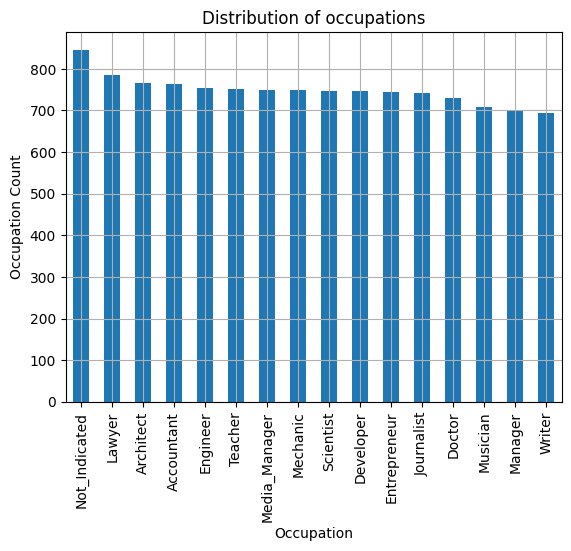

In [22]:
# Path to the folder containing CSV files
folder_path = silver_attributes_directory

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df_attr = spark.read.option("header", "true").parquet(*files_list)

# visualise bad rate
pdf = df_attr.toPandas()

# Group by col_A and count occurrences in col_B
grouped = pdf['Occupation'].value_counts()

# Plotting
grouped.plot(kind='bar')
plt.title("Distribution of occupations")
plt.xlabel('Occupation')
plt.ylabel('Occupation Count')
plt.grid(True)
plt.show()


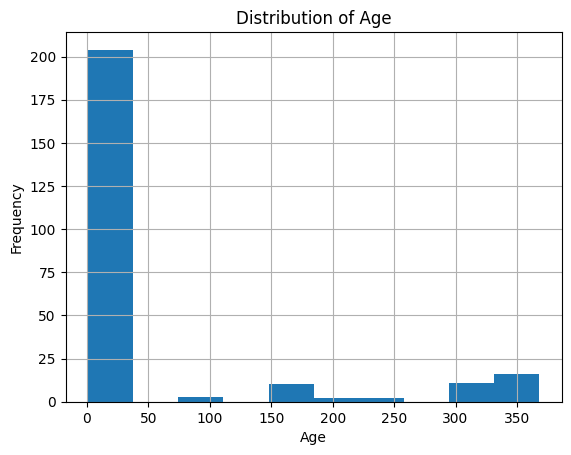

In [23]:
grouped = pdf['Age'].value_counts()

# Plotting
grouped.plot(kind='hist')
plt.title("Distribution of Age")
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

The `Age` column seem to have invalid values that are more than 100 - have to further clean the `Age` column - add indicator flag (`Age_out_of_range` and `Age_clean` which will be within normal range).

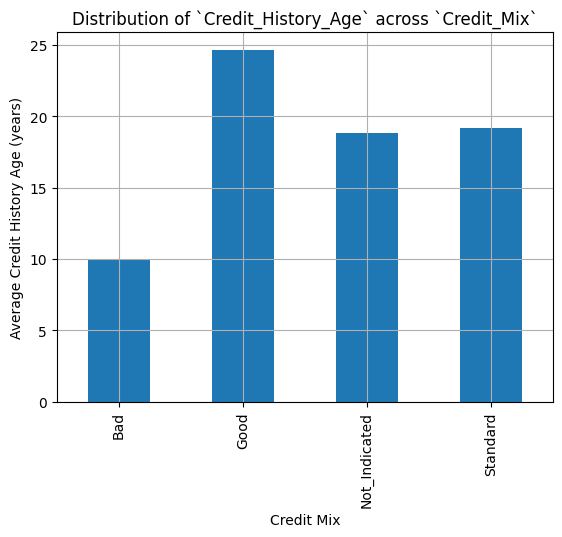

In [24]:
# Path to the folder containing CSV files
folder_path = silver_financials_directory

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df_financials = spark.read.option("header", "true").parquet(*files_list)

# visualise bad rate
pdf = df_financials.toPandas()

# Group by col_A and count occurrences in col_B
grouped = pdf.groupby("Credit_Mix")['Credit_History_Age'].mean()

# Plotting
grouped.plot(kind='bar')
plt.title("Distribution of `Credit_History_Age` across `Credit_Mix`")
plt.xlabel('Credit Mix')
plt.ylabel('Average Credit History Age (years)')
plt.grid(True)
plt.show()

The mean `Credit_History_Age` for Bad `Credit_Mix` is lower than the other `Credit_Mix` categories (at around 10 years), which supports the notion that those with better `Credit_Mix` tend to have longer `Credit_History_Age`. Hence, a threshold of 10 will be used to create a flag.

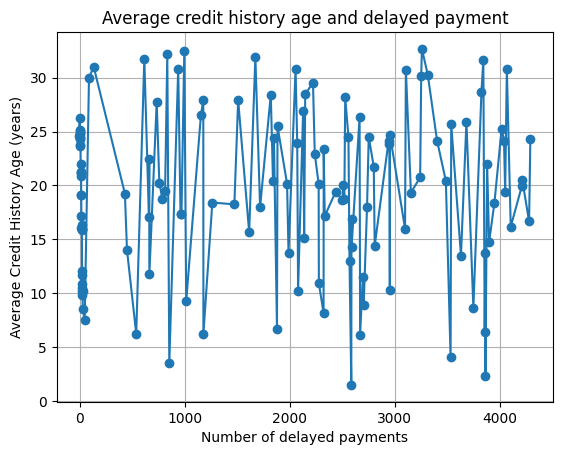

In [25]:
# Group by col_A and count occurrences in col_B
grouped = pdf.groupby("Num_of_Delayed_Payment")["Credit_History_Age"].mean()

# Plotting
grouped.plot(kind='line', marker="o")
plt.title("Average credit history age and delayed payment")
plt.xlabel('Number of delayed payments')
plt.ylabel('Average Credit History Age (years)')
plt.grid(True)
plt.show()

There does not seem to have a clear pattern between number of delayed payment and average credit history age.

## EDA for credit labels creation
This is obtained from `lab_2` where EDA was done to explore the threshold of dpd to be set to consider the customer as bad debts

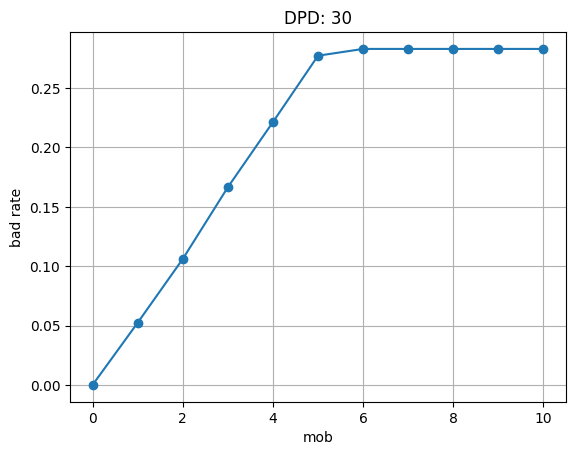

In [26]:
# set dpd label definition
dpd = 30

# Path to the folder containing CSV files
folder_path = silver_loan_daily_directory

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)

# filter only completed loans
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd - dpd=date past due
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# actual bads - threshold to determine 
actual_bads_df = df.filter(col("installment_num") == 10)

# prepare for analysis
# df = df.filter(col("installment_num") < 10)

# visualise bad rate
pdf = df.toPandas()

# Group by col_A and count occurrences in col_B
grouped = pdf.groupby('mob')['dpd_flag'].mean()

# Sort the index (x-axis) of the grouped DataFrame
grouped = grouped.sort_index()

# Plotting
grouped.plot(kind='line', marker='o')

plt.title('DPD: '+ str(dpd))
plt.xlabel('mob')
plt.ylabel('bad rate')
plt.grid(True)
plt.show()


**Determine the actual threshold (mob value) to classify client as actual bad debt**

In [27]:
df.show()

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|installments_missed|first_missed_date|dpd|dpd_flag|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|CUS_0x5572_2023_1...| CUS_0x5572|     2023-12-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-09-01|  9|                  0|             NULL|  0|       0|
|CUS_0x81d_2023_12_01|  CUS_0x81d|     2023-12-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-09-01|  9|                  0|             NULL|  0|       0|
|CUS_0x7af8_2023_1...| CUS_0x7af8|     2023-12-01|    1

## Build gold table for labels

In [14]:
# create gold datalake
gold_feature_store_directory = "datamart/gold/feature_store/"
gold_label_store_directory = "datamart/gold/label_store/"

if not os.path.exists(gold_feature_store_directory):
    os.makedirs(gold_feature_store_directory)

if not os.path.exists(gold_label_store_directory):
    os.makedirs(gold_label_store_directory)

In [15]:
# run gold backfill
for date_str in dates_str_lst:
    utils.data_processing_gold_table.process_features_gold_table(date_str, gold_feature_store_directory, spark, mob = 6)
    utils.data_processing_gold_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6)

loaded from:  datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet row count:  530
loaded from:  datamart/silver/clickstream/silver_clickstream_2023_01_01.parquet row count:  8974
loaded: attributes_df
loaded: financials_df


saved to: datamart/gold/feature_store/gold_feature_store_2023_01_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet row count: 530


saved to: datamart/gold/label_store/gold_label_store_2023_01_01.parquet
loaded from:  datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet row count:  1031


loaded from:  datamart/silver/clickstream/silver_clickstream_2023_02_01.parquet row count:  8974
loaded: attributes_df
loaded: financials_df


saved to: datamart/gold/feature_store/gold_feature_store_2023_02_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet row count: 1031


...

saved to: datamart/gold/feature_store/gold_feature_store_2024_11_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_11_01.parquet row count: 5501


saved to: datamart/gold/label_store/gold_label_store_2024_11_01.parquet
loaded from:  datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet row count:  5531


loaded from:  datamart/silver/clickstream/silver_clickstream_2024_12_01.parquet row count:  8974
loaded: attributes_df
loaded: financials_df


saved to: datamart/gold/feature_store/gold_feature_store_2024_12_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet row count: 5531


saved to: datamart/gold/label_store/gold_label_store_2024_12_01.parquet


In [16]:
utils.data_processing_gold_table.process_features_gold_table(date_str, gold_feature_store_directory, spark, mob = 6).dtypes

loaded from:  datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet row count:  5531
loaded from:  datamart/silver/clickstream/silver_clickstream_2024_12_01.parquet row count:  8974
loaded: attributes_df
loaded: financials_df


saved to: datamart/gold/feature_store/gold_feature_store_2024_12_01.parquet


[('Customer_ID', 'string'),
 ('snapshot_date', 'date'),
 ('fe_1', 'int'),
 ('fe_2', 'int'),
 ('fe_3', 'int'),
 ('fe_4', 'int'),
 ('fe_5', 'int'),
 ('fe_6', 'int'),
 ('fe_7', 'int'),
 ('fe_8', 'int'),
 ('fe_9', 'int'),
 ('fe_10', 'int'),
 ('fe_11', 'int'),
 ('fe_12', 'int'),
 ('fe_13', 'int'),
 ('fe_14', 'int'),
 ('fe_15', 'int'),
 ('fe_16', 'int'),
 ('fe_17', 'int'),
 ('fe_18', 'int'),
 ('fe_19', 'int'),
 ('fe_20', 'int'),
 ('Age_clean', 'int'),
 ('Age_out_of_range', 'boolean'),
 ('Occupation', 'string'),
 ('Occupation_invalid', 'boolean'),
 ('Annual_Income_clean', 'int'),
 ('Monthly_Inhand_Salary_clean', 'int'),
 ('Num_Bank_Accounts_clean', 'int'),
 ('Num_Credit_Card_clean', 'int'),
 ('Interest_Rate_clean', 'int'),
 ('Num_of_Loan_clean', 'int'),
 ('Num_of_Delayed_Payment_clean', 'int'),
 ('Outstanding_Debt_clean', 'int'),
 ('Credit_Mix', 'string'),
 ('Credit_Utilization_Ratio', 'float'),
 ('Total_EMI_per_month_clean', 'int'),
 ('Monthly_Balance_clean', 'int'),
 ('Annual_Income_negativ

## Inspect feature store

In [20]:
folder_path = gold_feature_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:",df.count())

df.show()

row_count: 8974
+-----------+-------------+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+---------+----------------+-------------+------------------+-------------------+---------------------------+-----------------------+---------------------+-------------------+-----------------+----------------------------+----------------------+-------------+------------------------+-------------------------+---------------------+----------------------+------------------------------+--------------------------+------------------------+----------------------+--------------------+-------------------------------+-------------------------+----------------------------+------------------------+----------+------------------+
|Customer_ID|snapshot_date|fe_1|fe_2|fe_3|fe_4|fe_5|fe_6|fe_7|fe_8|fe_9|fe_10|fe_11|fe_12|fe_13|fe_14|fe_15|fe_16|fe_17|fe_18|fe_19|fe_20|Age_clean|Age_out_of_range|   Occupation|Occupation_invalid|Annual_Income_clean|Mont

In [21]:
df.printSchema()

root
 |-- Customer_ID: string (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- fe_1: integer (nullable = true)
 |-- fe_2: integer (nullable = true)
 |-- fe_3: integer (nullable = true)
 |-- fe_4: integer (nullable = true)
 |-- fe_5: integer (nullable = true)
 |-- fe_6: integer (nullable = true)
 |-- fe_7: integer (nullable = true)
 |-- fe_8: integer (nullable = true)
 |-- fe_9: integer (nullable = true)
 |-- fe_10: integer (nullable = true)
 |-- fe_11: integer (nullable = true)
 |-- fe_12: integer (nullable = true)
 |-- fe_13: integer (nullable = true)
 |-- fe_14: integer (nullable = true)
 |-- fe_15: integer (nullable = true)
 |-- fe_16: integer (nullable = true)
 |-- fe_17: integer (nullable = true)
 |-- fe_18: integer (nullable = true)
 |-- fe_19: integer (nullable = true)
 |-- fe_20: integer (nullable = true)
 |-- Age_clean: integer (nullable = true)
 |-- Age_out_of_range: boolean (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- Occupation_invalid: 

## Inspect label store

In [22]:
folder_path = gold_label_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:",df.count())

df.show()

row_count: 8974
+--------------------+-----------+-----+----------+-------------+
|             loan_id|Customer_ID|label| label_def|snapshot_date|
+--------------------+-----------+-----+----------+-------------+
|CUS_0x3bf5_2023_0...| CUS_0x3bf5|    0|30dpd_6mob|   2023-07-01|
|CUS_0x19d1_2023_0...| CUS_0x19d1|    1|30dpd_6mob|   2023-07-01|
|CUS_0x1a9c_2023_0...| CUS_0x1a9c|    0|30dpd_6mob|   2023-07-01|
|CUS_0x37b2_2023_0...| CUS_0x37b2|    0|30dpd_6mob|   2023-07-01|
|CUS_0x3e54_2023_0...| CUS_0x3e54|    0|30dpd_6mob|   2023-07-01|
|CUS_0x3b2a_2023_0...| CUS_0x3b2a|    0|30dpd_6mob|   2023-07-01|
|CUS_0x3bc6_2023_0...| CUS_0x3bc6|    1|30dpd_6mob|   2023-07-01|
|CUS_0x19ad_2023_0...| CUS_0x19ad|    0|30dpd_6mob|   2023-07-01|
|CUS_0x2de0_2023_0...| CUS_0x2de0|    1|30dpd_6mob|   2023-07-01|
|CUS_0x1341_2023_0...| CUS_0x1341|    0|30dpd_6mob|   2023-07-01|
|CUS_0x3fc3_2023_0...| CUS_0x3fc3|    0|30dpd_6mob|   2023-07-01|
|CUS_0x4271_2023_0...| CUS_0x4271|    0|30dpd_6mob|   2023-0

In [21]:
df.printSchema()

root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- label_def: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

